In [1]:
import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [3]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
import random
import umap
from models.modules import *

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from scripts.run_model import *

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
############################################################

In [9]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [10]:
from simulate.simulate import *

In [11]:
### SETTINGS ###

dataname = "diamond"
size = 5000
d = 2 #dummy dimension

In [12]:
############################################################

In [13]:
dic = {"s": sample_s,
       "s_imbalanced": sample_s_imbalanced,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega}
adata = process_fake_data(size, d, dic[dataname])

In [14]:
adata

AnnData object with n_obs × n_vars = 5000 × 2
    obs: 'timepoint', 'gene_target', 'cell_type', 'cell_type_one_hot'
    uns: 'std', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [15]:
dataset = extract_paired_dataset(adata)

In [16]:
############################################################

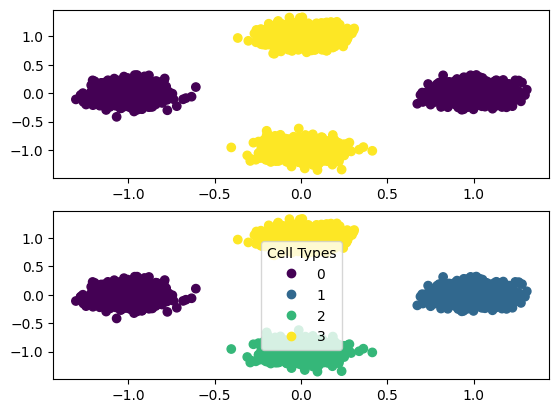

In [34]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(2)
axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
scatter = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [18]:
config = Config(
    {        
        "classifier_max_epochs": 500,
        "metric_max_epochs": 1000,
        "embed_max_epochs": 5000,
        "flow_max_epochs": 2000,
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": d,
        "num_classes": adata.obs['cell_type'].nunique(),
        "hidden_dim": 256,
        "latent_dim": 100,
        "score_batch_size": 2048,
        "flow_batch_size": 512,
        "num_freq": 32,
        "num_layers": 4,
        "force_cpu": False,
        "detect_anomaly": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 6,
        "warmup_steps": 0,
        "ema_decay": 1-1e-3,
        "ot_in_embed": True,
        "fast_ot": False,
        "skip": False,
        "rescale": 0.5,
        "sigma": 0.05,

        "metric": "cfm",

        #MFM parameters
        "K": 500,
        "kappa": 1.0,
        "alpha": 1.0,
        "epsilon": 1e-2,

        #Finsler parameters
        "use_finsler": True,
        "finsler_temp": 1.0,
        "finsler_lamb": 1.0,
    }
)

project = "ffm-ipynb"

In [19]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, dataset)

Running phase classifier:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇████
train_loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
epoch,499
train_loss,0.00019
trainer/global_step,999


Running phase metric:.......


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 225 K  | train
1 | geo_net      | SinNet         | 217 K  | train
2 | metric_model | FinslerCFM     | 201 K  | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
443 K     Trainable params
201 K     Non-trainable params
644 K     Total params
2.579     Total estimated

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇████
train_loss_embed,█▇▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_geo,█▅▅▄▃▄▄▂▄▃▃▂▃▂▃▂▄▃▃▂▃▂▃▄▂▁▁▃▃▂▃▃▄▁▃▂▃▄▂▄
trainer/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇█████
epoch,4999
train_loss_embed,1.6408
train_loss_geo,294.901
trainer/global_step,4999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | flow_net    | SinNet                   | 217 K  | train
1 | embed_model | FinslerEmbedNetTrainBase | 644 K  | eval 
-----------------------------------------------------------------
217 K     Trainable params
644 K     Non-trainable params
861 K     Total params
3.447     Total estimated model params size (MB)
16        Modules in train mode
5

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█
train_loss,█▃▃▃▃▂▂▄▂▃▃▂▂▃▂▄▁▃▂▁▅▂▂▂▂▂▁▂▁▂▂▁▂▂▂▃▁▁▂▁
trainer/global_step,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
epoch,1999
train_loss,0.10755
trainer/global_step,1999


In [20]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

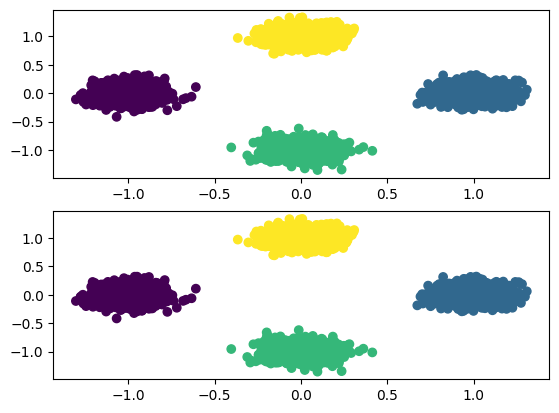

In [21]:
if config.use_finsler:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X).argmax(dim=1)

    fig, axs = plt.subplots(2)
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    plt.show()
    

In [22]:
#NOTE: only works for MFM
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    print(metric_model.M(z.to('cuda')).detach().shape)

    E = metric_model.M(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [23]:
if config.metric == "mfm":
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_metric(metric_model, samples)

In [24]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

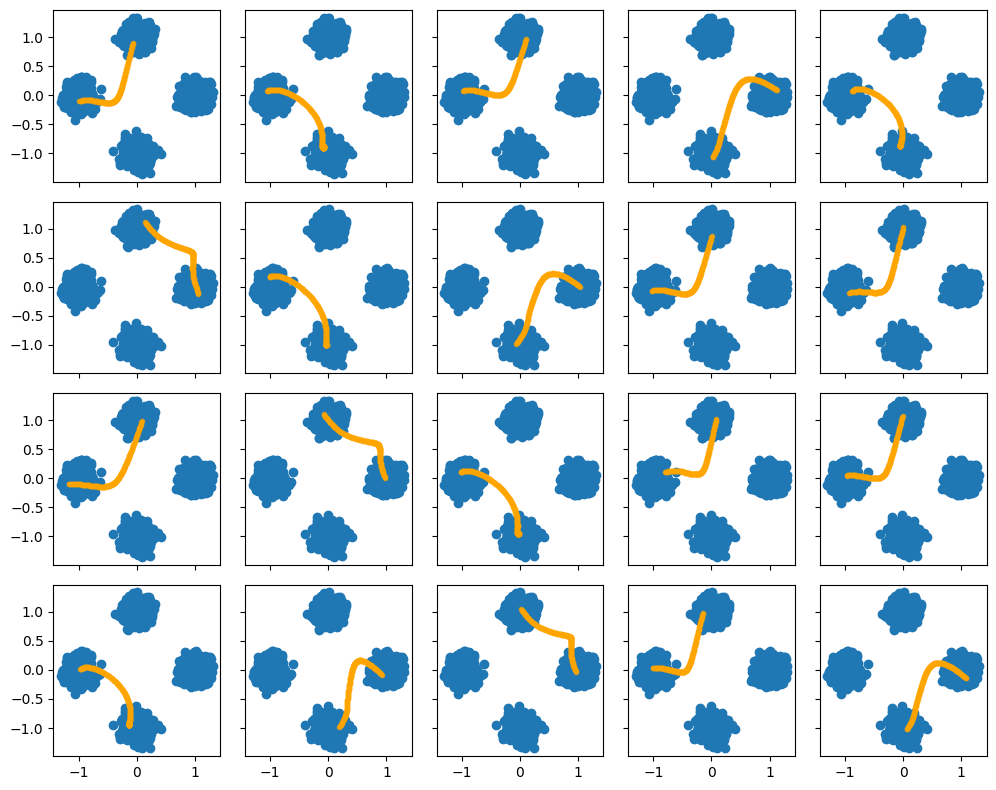

In [25]:
#GEO VALIDATION
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

In [33]:
#EMBED VALIDATION
if config.metric == "cfm" and not config.use_finsler:
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

In [27]:
#FLOW VALIDATION

num_samples = 500
steps = 500

In [28]:
from datasets.dataset import sample
def plot_flow(t0):
    t1 = t0 + 1
    x = adata[adata.obs['timepoint'].astype(int) == t0].obsm['X_pca']
    x = sample(x, min(num_samples, x.shape[0]))
    x = torch.from_numpy(x).float()
    traj = flow_model.sample_traj(x, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

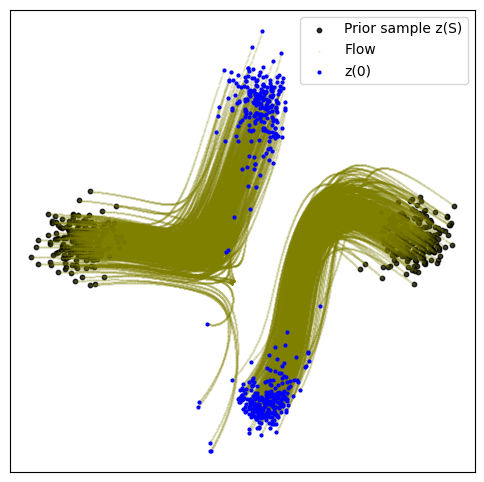

In [29]:
plot_flow(0)

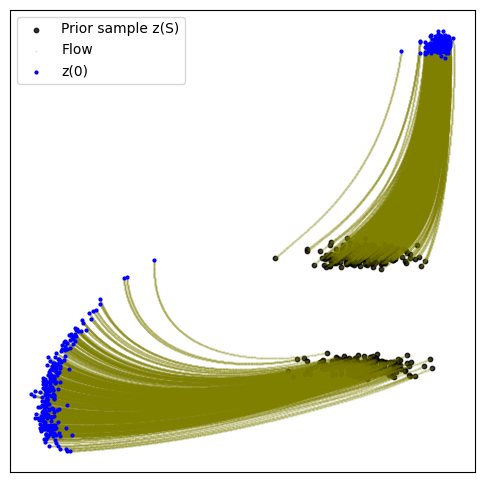

In [30]:
plot_flow(1)

In [31]:
plot_flow(2)

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
plot_flow(3)

In [ ]:
plot_flow(4)